# Demonstração: Modelo Pinhole (Câmera de Orifício)

Seminário Relâmpago - Processamento de Imagem - CESUPA  
Tema 5: Modelo Pinhole - como o mundo 3D vira uma imagem 2D

Este notebook mostra, de forma bem simples, a ideia central do modelo pinhole: todo ponto 3D (X, Y, Z) do mundo é projetado em um ponto 2D (x', y') na "imagem" através de UMA ÚNICA equação, usando a distância focal f:

$$ x' = f \cdot \frac{X}{Z} \qquad y' = f \cdot \frac{Y}{Z} $$

Ou seja: quanto mais LONGE um ponto está da câmera (Z grande), menor ele aparece na imagem — é exatamente a ideia de perspectiva.


## 0. Imports


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d.art3d import Line3DCollection
from matplotlib.collections import LineCollection


## 1. Cena 3D

Um cubo simples "na frente" da câmera (câmera na origem, olhando para o eixo +Z).


In [ ]:
f = 1.0  # distância focal (unidade arbitrária)

# 8 vértices de um cubo, deslocado no eixo Z para ficar "na frente" da câmera
cubo = np.array([
    [-1, -1, 4], [1, -1, 4], [1, 1, 4], [-1, 1, 4],   # face de trás (mais longe)
    [-0.6, -0.6, 2], [0.6, -0.6, 2], [0.6, 0.6, 2], [-0.6, 0.6, 2],  # face da frente (mais perto)
])

# arestas do cubo (pares de índices) para desenhar as linhas
arestas = [
    (0, 1), (1, 2), (2, 3), (3, 0),      # face de trás
    (4, 5), (5, 6), (6, 7), (7, 4),      # face da frente
    (0, 4), (1, 5), (2, 6), (3, 7),      # conectando as duas faces
]


## 2. Projeção pinhole

Aplica x' = f*X/Z, y' = f*Y/Z em cada vértice.


In [ ]:
def projeta(pontos_3d, f):
    X, Y, Z = pontos_3d[:, 0], pontos_3d[:, 1], pontos_3d[:, 2]
    x_linha = f * (X / Z)
    y_linha = f * (Y / Z)
    return np.stack([x_linha, y_linha], axis=1)

pontos_2d = projeta(cubo, f)
pontos_2d


array([[-0.25, -0.25],
       [ 0.25, -0.25],
       [ 0.25,  0.25],
       [-0.25,  0.25],
       [-0.3 , -0.3 ],
       [ 0.3 , -0.3 ],
       [ 0.3 ,  0.3 ],
       [-0.3 ,  0.3 ]])

## 3. Visualização


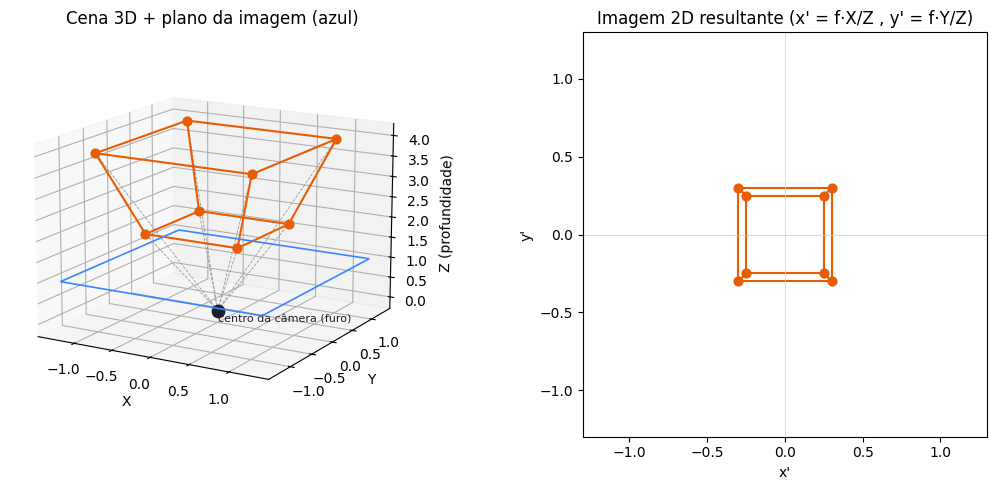

Gerado: projecao_pinhole.png


In [ ]:
fig = plt.figure(figsize=(11, 5))

# --- Painel 1: cena 3D ---
ax1 = fig.add_subplot(1, 2, 1, projection="3d")
ax1.scatter(*cubo.T, color="#E85D04", s=40, depthshade=False)
linhas_3d = [(cubo[i], cubo[j]) for i, j in arestas]
ax1.add_collection3d(Line3DCollection(linhas_3d, colors="#E85D04", linewidths=1.5))

# desenha o "centro de projeção" (furo) na origem
ax1.scatter([0], [0], [0], color="#1B1F27", s=80, marker="o")
ax1.text(0, 0, -0.3, "centro da câmera (furo)", color="#1B1F27", fontsize=8)

# raios de projeção (linhas do furo até cada vértice)
for p in cubo:
    ax1.plot([0, p[0]], [0, p[1]], [0, p[2]], color="#999999", linewidth=0.6, linestyle="--")

# plano da imagem (em Z = f), apenas ilustrativo
plano = np.array([[-1.3, -1.3, f], [1.3, -1.3, f], [1.3, 1.3, f], [-1.3, 1.3, f]])
ax1.add_collection3d(Line3DCollection(
    [(plano[i], plano[(i + 1) % 4]) for i in range(4)],
    colors="#3A86FF", linewidths=1.2))

ax1.set_xlabel("X")
ax1.set_ylabel("Y")
ax1.set_zlabel("Z (profundidade)")
ax1.set_title("Cena 3D + plano da imagem (azul)")
ax1.view_init(elev=15, azim=-60)

# --- Painel 2: imagem 2D projetada ---
ax2 = fig.add_subplot(1, 2, 2)
linhas_2d = [(pontos_2d[i], pontos_2d[j]) for i, j in arestas]
ax2.add_collection(LineCollection(linhas_2d, colors="#E85D04", linewidths=1.5))
ax2.scatter(pontos_2d[:, 0], pontos_2d[:, 1], color="#E85D04", s=40, zorder=3)
ax2.set_xlim(-1.3, 1.3)
ax2.set_ylim(-1.3, 1.3)
ax2.set_aspect("equal")
ax2.set_title("Imagem 2D resultante (x' = f·X/Z , y' = f·Y/Z)")
ax2.set_xlabel("x'")
ax2.set_ylabel("y'")
ax2.axhline(0, color="#cccccc", linewidth=0.5)
ax2.axvline(0, color="#cccccc", linewidth=0.5)

plt.tight_layout()
plt.savefig("projecao_pinhole.png", dpi=180, facecolor="white")
plt.show()
print("Gerado: projecao_pinhole.png")


## Ponto-chave para falar na apresentação

A face do cubo mais LONGE da câmera (Z=4) aparece MENOR na imagem 2D do que a face mais PERTO (Z=2) — mesma proporção X/Y, tamanho projetado diferente. Isso é a perspectiva, e é a base de tudo: calibração de câmeras, realidade aumentada, robótica e reconstrução 3D.
